In [16]:
# IS477 Final Project: USD Strength vs. U.S. Export Competitiveness
# Authors: Prajeeta Dahal, Shannon Choi
#
# This script acquires data from the FRED API, integrates and cleans the datasets,
# runs correlation and lag analysis, saves output files, and prints a SHA-256
# checksum of the merged dataset for reproducibility verification.
#
# Run: pip install fredapi pandas matplotlib
# Then set your FRED API key below before running.

# ── 0. Install (uncomment if running in Colab) ────────────────────────────────
!pip install fredapi

# ── 1. Imports ────────────────────────────────────────────────────────────────
import hashlib
import os
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

In [17]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
# Replace with your own free FRED API key from https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = 'YOUR_API_KEY_HERE'

# Output directory — will be created if it doesn't exist
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [18]:
# ── 3. Data Acquisition ───────────────────────────────────────────────────────
print("Acquiring data from FRED API...")
fred = Fred(api_key='ecd5252612b65ff032f9f365bd3adffb')

Acquiring data from FRED API...


In [19]:
# Real Trade Weighted USD Index (monthly)
dollar = fred.get_series('RTWEXBGS')
dollar = dollar.to_frame(name='RTWEXBGS')
dollar.index = pd.to_datetime(dollar.index)
dollar

,RTWEXBGS
2006-01-01,100.0000
2006-02-01,100.2393
2006-03-01,100.5329
2006-04-01,100.0359
2006-05-01,97.8540
...,...
2025-11-01,115.3855
2025-12-01,114.3510
2026-01-01,113.5201
2026-02-01,113.5106


In [20]:
# Real Exports of Goods and Services (quarterly)
fred = Fred(api_key='ecd5252612b65ff032f9f365bd3adffb')
exports = fred.get_series('EXPGS')
exports = exports.to_frame(name='EXPGS')
exports.index = pd.to_datetime(exports.index)
exports

,EXPGS
1946-01-01,NaN
1946-04-01,NaN
1946-07-01,NaN
1946-10-01,NaN
1947-01-01,18.394
...,...
2024-10-01,3248.255
2025-01-01,3293.661
2025-04-01,3267.506
2025-07-01,3366.868


In [21]:
print(f"  RTWEXBGS: {len(dollar)} monthly observations")
print(f"  EXPGS:    {len(exports)} quarterly observations")

  RTWEXBGS: 243 monthly observations
  EXPGS:    320 quarterly observations


In [22]:
# ── 4. Data Integration ───────────────────────────────────────────────────────
print("\nIntegrating datasets...")

# Downsample monthly Dollar Index to quarterly averages
dollar_q = dollar.resample('Q').mean()
dollar_q.index = dollar_q.index.to_period('Q')

# Convert exports to quarterly PeriodIndex (resolves timestamp mismatch)
exports.index = exports.index.to_period('Q')

# Create 2-quarter lag on exports (original hypothesis)
exports['EXPGS_lag2'] = exports['EXPGS'].shift(2)

# Inner join on aligned quarterly PeriodIndex
merged = pd.merge(dollar_q, exports, left_index=True, right_index=True, how='inner')
print(f"  Merged shape: {merged.shape}")


Integrating datasets...
  Merged shape: (80, 3)


/tmp/ipykernel_9773/3499941177.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dollar_q = dollar.resample('Q').mean()


In [23]:
# ── 5. Data Cleaning & Transformation ─────────────────────────────────────────
print("\nApplying transformations...")

# Percentage change to address non-stationarity
merged['usd_pct']     = merged['RTWEXBGS'].pct_change()
merged['exports_pct'] = merged['EXPGS_lag2'].pct_change()

# Drop NaNs introduced by shift() and pct_change()
merged = merged.dropna()
print(f"  Clean merged shape (after dropna): {merged.shape}")



Applying transformations...
  Clean merged shape (after dropna): (79, 5)


In [24]:
# ── 6. Save Merged Dataset ────────────────────────────────────────────────────
csv_path = os.path.join(OUTPUT_DIR, 'merged_dataset.csv')
merged.to_csv(csv_path)
print(f"\nSaved merged dataset to: {csv_path}")


Saved merged dataset to: outputs/merged_dataset.csv


In [25]:
# SHA-256 integrity check
with open(csv_path, 'rb') as f:
    file_hash = hashlib.sha256(f.read()).hexdigest()
print(f"  SHA-256 checksum: {file_hash}")
print("  (Save this checksum to verify the file hasn't changed when reproducing results.)")


  SHA-256 checksum: 10d8a84f1c8324e3cc740a3d23e12499e79307b0abf71c44340cfa404207dcff
  (Save this checksum to verify the file hasn't changed when reproducing results.)


In [26]:
# ── 7. Analysis: Baseline Correlation ─────────────────────────────────────────
print("\n── Baseline Correlation (lag-2 specification) ──")
baseline_corr = merged['usd_pct'].corr(merged['exports_pct'])
print(f"  Pearson r (USD % change vs. 2Q-lagged exports % change): {baseline_corr:.4f}")



── Baseline Correlation (lag-2 specification) ──
  Pearson r (USD % change vs. 2Q-lagged exports % change): 0.2230


In [27]:
# ── 8. Analysis: Lag 0–4 Correlations ─────────────────────────────────────────
print("\n── Lag Analysis (lags 0–4 quarters) ──")
lag_results = {}
for i in range(5):
    lagged_exports = merged['EXPGS'].shift(i).pct_change()
    # Align index with usd_pct
    combined = pd.concat([merged['usd_pct'], lagged_exports], axis=1).dropna()
    combined.columns = ['usd_pct', f'exports_lag{i}']
    r = combined['usd_pct'].corr(combined[f'exports_lag{i}'])
    lag_results[i] = r
    print(f"  Lag {i}: r = {r:.4f}")


── Lag Analysis (lags 0–4 quarters) ──
  Lag 0: r = -0.4723
  Lag 1: r = 0.0524
  Lag 2: r = 0.2351
  Lag 3: r = 0.1872
  Lag 4: r = 0.0308


In [28]:
# ── 9. Analysis: Pre- and Post-2020 ───────────────────────────────────────────
print("\n── Pre/Post-2020 Analysis (no lag, percentage change) ──")
pre_2020  = merged[merged.index < '2020Q1']
post_2020 = merged[merged.index >= '2020Q1']

pre_corr  = pre_2020['usd_pct'].corr(pre_2020['exports_pct'])
post_corr = post_2020['usd_pct'].corr(post_2020['exports_pct'])
print(f"  Pre-2020  r: {pre_corr:.4f}  ({len(pre_2020)} quarters)")
print(f"  Post-2020 r: {post_corr:.4f}  ({len(post_2020)} quarters)")



── Pre/Post-2020 Analysis (no lag, percentage change) ──
  Pre-2020  r: 0.1846  (55 quarters)
  Post-2020 r: 0.3234  (24 quarters)


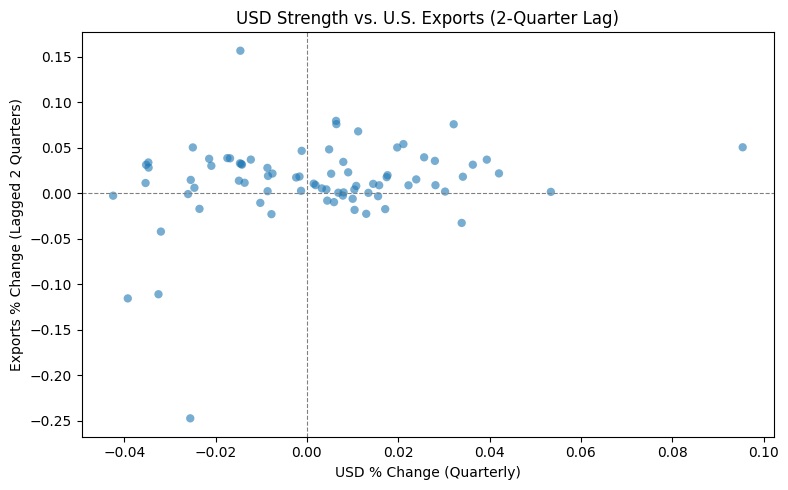


Saved scatter plot to: outputs/usd_vs_exports_scatter.png

── Analysis complete. All outputs saved to the 'outputs/' folder. ──


In [29]:
# ── 10. Visualization: Scatter Plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(merged['usd_pct'], merged['exports_pct'], alpha=0.6, edgecolors='none')
ax.set_xlabel('USD % Change (Quarterly)')
ax.set_ylabel('Exports % Change (Lagged 2 Quarters)')
ax.set_title('USD Strength vs. U.S. Exports (2-Quarter Lag)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, 'usd_vs_exports_scatter.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nSaved scatter plot to: {plot_path}")

print("\n── Analysis complete. All outputs saved to the 'outputs/' folder. ──")
